In [1]:
%load_ext autoreload
%autoreload 2

from qiskit import QuantumCircuit, transpile
from qiskit_aer import Aer, AerSimulator
from qiskit.providers.fake_provider import GenericBackendV2
from matplotlib import pyplot as plt
import sys
import numpy as np
from qiskit.quantum_info import Pauli
from qiskit_aer.noise import NoiseModel, pauli_error

sys.path.append("../../pauli_lindblad_per/")
from tomography.experiment import SparsePauliTomographyExperiment as tomography

plt.style.use("ggplot")

In [2]:
inst_map = [0,1]
n = 2
qc = QuantumCircuit(n)
qc.cx(0,1)
print(qc.draw())

coupling_list = [(0, 1), (1, 0)]

errorops = [Pauli("XY")]
errorprobs = [0.1]

# Erzeuge PauliError und NoiseModel
twoqubit_error = pauli_error([(op, p) for op, p in zip(errorops, errorprobs)] + [(Pauli("II"), 1 - sum(errorprobs))])
noise_model = NoiseModel()
noise_model.add_all_qubit_quantum_error(twoqubit_error, ['cx'])

backend = GenericBackendV2(num_qubits=n, coupling_map=coupling_list)

          
q_0: ──■──
     ┌─┴─┐
q_1: ┤ X ├
     └───┘


In [7]:
%%prun

experiment = tomography(
    circuits = [qc], #list of circuits from which to get the layers requiring tomography
    inst_map = inst_map, #which physical qubits on the processor to map the qubits in the circuit
    backend = backend, #quantum backend
    used_qubits=[0,1]
    )

experiment.generate(
    samples = 100, #Number of samples to take from the fidelity pair measurements
    single_samples = 250, #samples to take from the pair-breaking measurements
    depths = [2,4,16,32,64] #values of 2n to make the pair measurements. Numbers must be even and non-zero
    )

shots = 1024
def executor(circuits):
    return backend.run(circuits, shots = shots, noise_model=noise_model).result().get_counts()

#run the experiment
experiment.run(executor)

noisedataframe = experiment.analyze()
print("noise coefficients:", list(noisedataframe.noisemodels.values())[0].coeffs)
print("spam coefficients:", list(zip(noisedataframe.spam.keys(), noisedataframe.spam.values())))

noise coefficients: [(ZZ, np.float64(0.0)), (XX, np.float64(0.00031602466923050677)), (XY, np.float64(0.1110707371296)), (IX, np.float64(0.0)), (XZ, np.float64(0.0)), (ZI, np.float64(0.0)), (ZX, np.float64(0.00017200816870085645)), (YY, np.float64(0.0)), (YZ, np.float64(0.0)), (YI, np.float64(0.0)), (YX, np.float64(0.0)), (ZY, np.float64(3.476921250182864e-05)), (XI, np.float64(0.0)), (IY, np.float64(0.0)), (IZ, np.float64(0.0))]
spam coefficients: [(IX, np.float64(0.9966378450985262)), (ZI, np.float64(0.9972251431870688)), (YI, np.float64(0.9999999999448437)), (XI, np.float64(0.9999788589320225)), (IY, np.float64(0.9999788589320225)), (IZ, np.float64(0.9987161988652927))]
 

         243637818 function calls (242211538 primitive calls) in 434.645 seconds

   Ordered by: internal time

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
        3   40.390   13.463   40.390   13.463 {method 'acquire' of '_thread.lock' objects}
  1194451   13.503    0.000   15.210    0.000 base_pauli.py:474(_to_label)
    12000   13.324    0.001   13.375    0.001 commutative_cancellation.py:37(__init__)
  1562515   12.968    0.000   30.203    0.000 base_pauli.py:381(_from_array)
   519211   11.318    0.000   17.483    0.000 pauli.py:613(_from_label)
  1104000    9.247    0.000   47.688    0.000 <frozen importlib._bootstrap>:1022(_find_and_load)
  1672508    9.094    0.000    9.094    0.000 {method 'reduce' of 'numpy.ufunc' objects}
  2666720    8.888    0.000   75.730    0.000 pauli.py:166(__init__)
  2208000    8.568    0.000   18.525    0.000 <frozen importlib._bootstrap>:179(_get_module_lock)
24571318/24321664    8.335    0.000   16.874    0.000 {built-

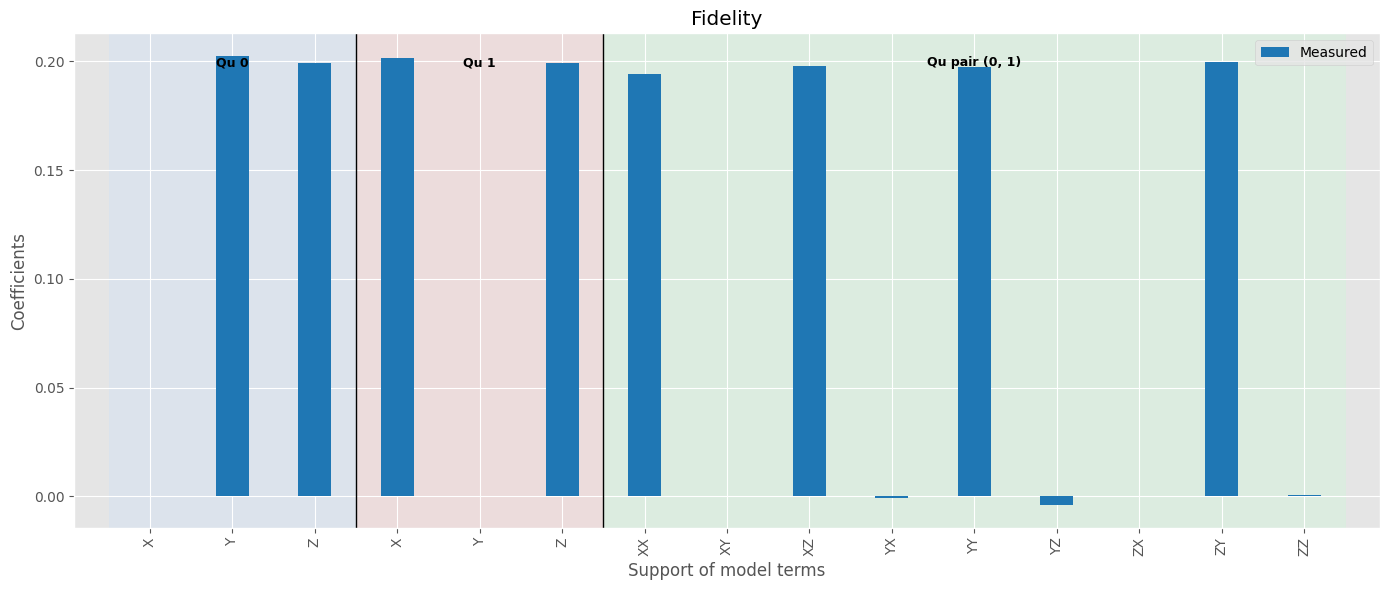

In [5]:
layer = experiment.analysis.get_layer_data(0)
layer.plot_infidelitites(plot_style = 2)

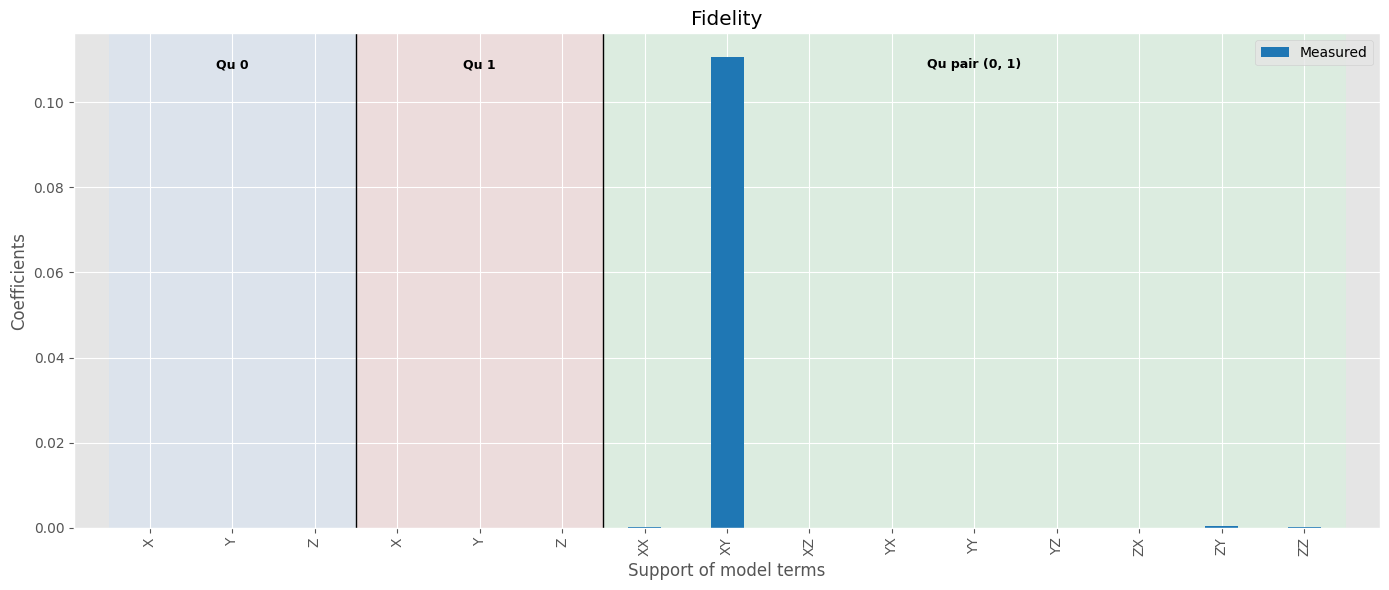

In [6]:
layer.plot_coeffs(plot_style = 2)